In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
from sklearn.cross_decomposition import PLSRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

sns.set_theme(style="whitegrid")

## 1. Load Data and work Plenty of Predictors
We expand continuous predictors into 2nd-degree polynomials to artificially create 50+ predictors for our PCR/PLS demonstration.

In [2]:
full_dataset = pd.read_csv("dataset.csv").dropna()
dataset = full_dataset[full_dataset["Profession"] == "Student"].reset_index(drop=True)
dataset = dataset.drop(columns=["id", "City", "Profession", "Work Pressure", "Job Satisfaction"])
dataset = dataset[dataset["Sleep Duration"] != "Others"].copy()
dataset = dataset[dataset["Dietary Habits"] != "Others"].copy()

y = dataset['Depression']
X = dataset.drop(columns=['Depression', 'Have you ever had suicidal thoughts ?'])

continuous_features = ['Age', 'CGPA', 'Academic Pressure', 'Work/Study Hours', 'Financial Stress', 'Study Satisfaction']
categorical_features = ['Gender', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Family History of Mental Illness']

# Create PolynomialFeatures to get "plenty of predictors" (Interaction terms + squares)
# For 6 continuous features, degree=2 produces 27 features instead of 6.
poly = PolynomialFeatures(degree=2, include_bias=False)

preprocessor = ColumnTransformer(
    transformers=[
        ('num_poly', Pipeline([('scaler1', StandardScaler()), ('poly', poly), ('scaler2', StandardScaler())]), continuous_features),
        ('cat', OneHotEncoder(drop="first", handle_unknown="ignore", sparse_output=False), categorical_features)
    ]
)

# Fit preprocessor just to check the number of predictors we generated
X_processed = preprocessor.fit_transform(X)
print(f"Original continuous features: {len(continuous_features)}")
print(f"Total predictors after Polynomial expansion {X_processed.shape[1]}")


Original continuous features: 6
Total predictors after Polynomial expansion 61


## 2. Principal Component Regression (PCR)
PCR is simply a pipeline consisting of PCA (for dimensionality reduction) followed by Logistic Regression.

In [3]:
# PCR Pipeline: Preprocess -> PCA -> Logistic Regression
pcr_model = Pipeline([
    ('preprocessor', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42)), # Keep 95% of variance
    ('classifier', LogisticRegression(class_weight='balanced', max_iter=2000, random_state=42))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
pcr_scores = cross_val_score(pcr_model, X, y, cv=cv, scoring='roc_auc')

print("--- Principal Component Regression (PCR) Results ---")
print(f"Mean 5-Fold ROC-AUC: {pcr_scores.mean():.4f} (+/- {pcr_scores.std():.4f})")


--- Principal Component Regression (PCR) Results ---
Mean 5-Fold ROC-AUC: 0.8665 (+/- 0.0064)


## 3. Partial Least Squares (PLS-DA)
Instead of blind variance reduction, PLS compresses features based on their correlation to the target variable (`Depression`). Because PLSRegression outputs continuous values, we threshold them at 0.5 to behave like a classifier.

In [4]:
from sklearn.base import BaseEstimator, TransformerMixin

class PLSTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, n_components=5):
        self.n_components = n_components
        
    def fit(self, X, y):
        self.pls_ = PLSRegression(n_components=self.n_components)
        self.pls_.fit(X, y)
        return self
        
    def transform(self, X):
        return self.pls_.transform(X)

pls_model = Pipeline([
    ("preprocessor", preprocessor),
    ("pls", PLSTransformer(n_components=10)),
    ("classifier", LogisticRegression(class_weight="balanced", max_iter=2000, random_state=42))
])

pls_scores = cross_val_score(pls_model, X, y, cv=cv, scoring="roc_auc")

print("--- Partial Least Squares (PLS-DA) Results ---")
print(f"Mean 5-Fold ROC-AUC: {pls_scores.mean():.4f} (+/- {pls_scores.std():.4f})")


--- Partial Least Squares (PLS-DA) Results ---
Mean 5-Fold ROC-AUC: 0.8728 (+/- 0.0065)


## 4. Visual Comparison (Confusion Matrices)

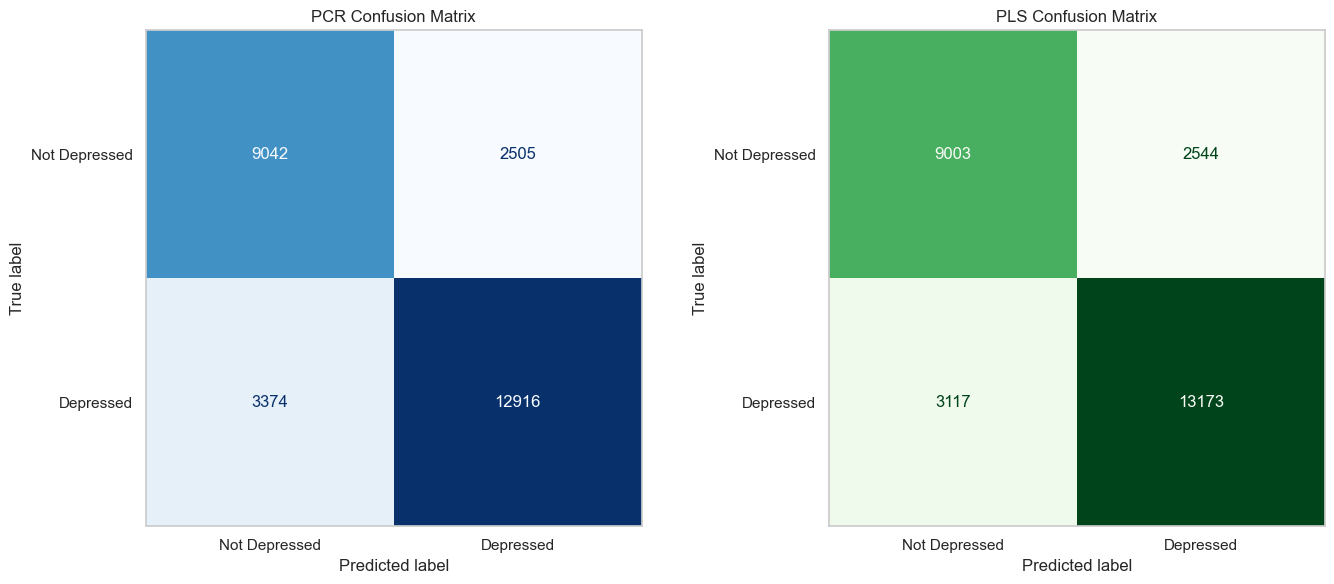

In [5]:
# Generate cross-validated predictions to plot confusion matrices
y_pred_pcr = cross_val_predict(pcr_model, X, y, cv=cv)
y_pred_pls = cross_val_predict(pls_model, X, y, cv=cv)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

cm_pcr = confusion_matrix(y, y_pred_pcr)
disp_pcr = ConfusionMatrixDisplay(confusion_matrix=cm_pcr, display_labels=["Not Depressed", "Depressed"])
disp_pcr.plot(cmap="Blues", ax=axes[0], colorbar=False)
axes[0].set_title("PCR Confusion Matrix")
axes[0].grid(False)

cm_pls = confusion_matrix(y, y_pred_pls)
disp_pls = ConfusionMatrixDisplay(confusion_matrix=cm_pls, display_labels=["Not Depressed", "Depressed"])
disp_pls.plot(cmap="Greens", ax=axes[1], colorbar=False)
axes[1].set_title("PLS Confusion Matrix")
axes[1].grid(False)

plt.tight_layout()
plt.show()
